<a href="https://colab.research.google.com/github/sudemasali/AI-Bootcamp-Projects-/blob/main/DeepLearningExample_pynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Yapay Sinir Ağları
Amaç:
 1. MNIST el yazısı rakamları veri seti kullanarak yapay sinir ağır ANN modeli ile sınıflandırma.
 2. Model, rakamları 0-9 şeklinde doğru şekilde tanımlamayı öğrenecek.

Veri seti:
 1. mnist: 28*28 piksel boyutlarında el yazısı ile yazılmış 0-9 arasında toplam 70000 görüntü içeriyor.
 2. 60000 tanesi training, 10000 tanesi test veri seti
Plan:
 1. Veri seti yükleme ve örnek görüntülerin görselleştirilmesi
 2. normalizasyon(0-1 arasına sıkıştırma)
 3. etiketlerin kategorik hale getirilmesi
 4. yapay sinir ağı mimarisinşn oluşturulması
 5. modelin derlenmesi
 6. erken durdurma (early stopping) en iyi modelin kaydedilmesi (model check poitn) callbacklerin kullanılması
 7. eğitim ve doğrulama metriklerinin görselleştirilmesi



In [20]:
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense # tam bağlı katman

import matplotlib.pyplot as plt

<function matplotlib.pyplot.show(close=None, block=None)>

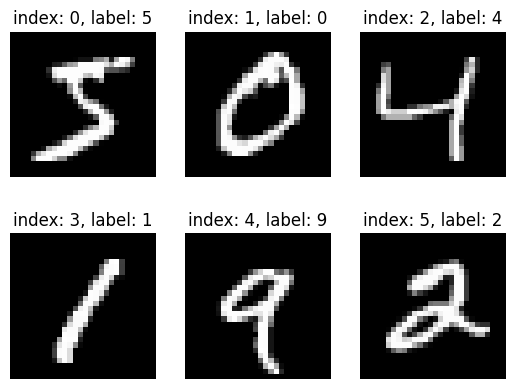

In [21]:
# veri setini yükle
(x_train,y_train) ,(x_test,y_test) = mnist.load_data()

# ilk bir kaç örneği görselleştir
plt.figure()
for i in range(6):
  plt.subplot(2,3,i+1)
  plt.imshow(x_train[i], cmap="gray")
  plt.title(f"index: {i}, label: {y_train[i]}")
  plt.axis("off")
plt.show


In [22]:
# veri setini normalize et
x_train = x_train.reshape(x_train.shape[0], x_train.shape[1]*x_train.shape[2]).astype("float32")/255 #60000, 28, 28 --> 60000,728
x_test = x_test.reshape(x_test.shape[0], x_test.shape[1]*x_test.shape[2]).astype("float32")/255


In [23]:
# etiketleri kategorik hale getir(etiketleri neural network ün anlayacağı formata çevirmek)
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10 ) #one-hot-encoding

In [24]:
# ann modeli
model = Sequential()

In [25]:
model.add(Dense(512, activation = "relu", input_shape = (28*28,)))
model.add(Dense(256, activation="tanh"))
model.add(Dense(10, activation= "softmax"))

In [26]:
model.compile(
    optimizer= "adam",
    loss = "categorical_crossentropy",
    metrics= ["accuracy"]
)

In [30]:
#callback tanımlama
early_stopping = EarlyStopping(monitor = "val_loss", patience= 5, restore_best_weights=True)

In [32]:
history = model.fit(
    x_train,
    y_train,
    epochs=2,
    batch_size=64,
    validation_split=0.2,
    callbacks=[early_stopping]
)

Epoch 1/2
750/750 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - accuracy: 0.9357 - loss: 0.2102 - val_accuracy: 0.9606 - val_loss: 0.1308
Epoch 2/2
750/750 ━━━━━━━━━━━━━━━━━━━━ 11s 12ms/step - accuracy: 0.9748 - loss: 0.0797 - val_accuracy: 0.9717 - val_loss: 0.0934


In [33]:
test_loss, teast_acc = model.evaluate(x_test, y_test)
print(teast_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9732 - loss: 0.0812
0.9732000231742859


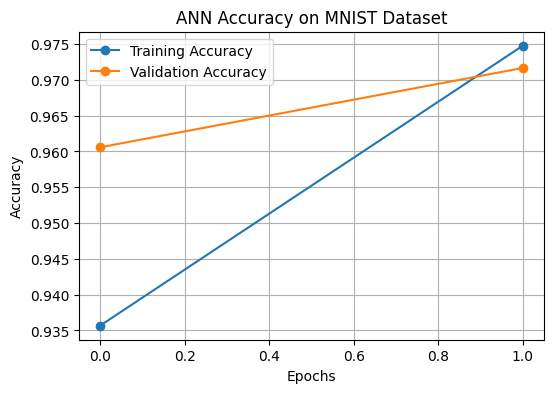

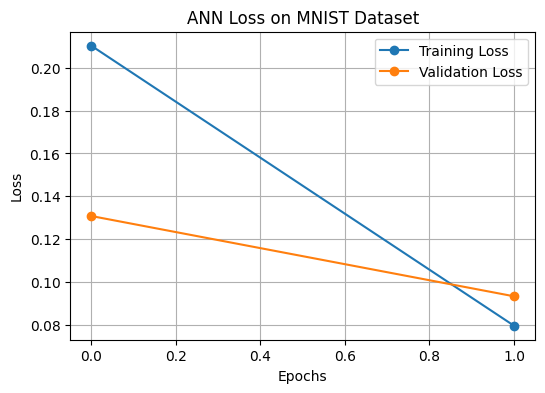

In [34]:

# accuracy training ve validation
plt.figure(figsize = (6,4))
plt.plot(history.history["accuracy"], marker = "o", label = "Training Accuracy")
plt.plot(history.history["val_accuracy"], marker = "o", label = "Validation Accuracy")
plt.title("ANN Accuracy on MNIST Dataset")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

# loss training ve validation
plt.figure(figsize = (6,4))
plt.plot(history.history["loss"], marker = "o", label = "Training Loss")
plt.plot(history.history["val_loss"], marker = "o", label = "Validation Loss")
plt.title("ANN Loss on MNIST Dataset")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()